In [ ]:
# Notebook env: brian_script_env (R kernel)

In [1]:
suppressMessages(library(dplyr))
suppressMessages(library(tidyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(ggridges))
suppressMessages(library(ggpubr))
## changes made selected_dose, graphing titles, filtering data for dose (see ## added for dose filtering), and sampling

selected_dose = '19.53nM'

In [2]:
## Extract metadata
## No pertinent data in Image besides total object counts per image -- not helpful for heterogeneity
## 5 sites per well, only using 3 sites (1, 2, and 4) due to image quality reasons (already filtered for before start of cellprofiler run)
## this was a 6 row x 12 column plate -- rows A-C were MIS18A-Ca, rows D-F were NT-Ca. The columns were serial dilutions of 2x starting with highest dose in first column at 5uM, 12th column is DMSO.

Image = read.csv('~/Desktop/Goodarzi_lab_stuff/heterogeneity_drivers_Brian_project/cellprofiler/dnmt3ai_dy_cellprof_out/Image.csv')
metadata = data.frame(ImageNumber = 1:nrow(Image), sample = Image$Metadata_Replicate, site = Image$Metadata_Site, dose = Image$FileName_DNA)
conditions = c('MIS18A-Ca', 'MIS18A-Ca', 'MIS18A-Ca', 'NT-Ca', 'NT-Ca', 'NT-Ca')
metadata$sample_name = plyr::mapvalues(metadata$sample, from = c('A', 'B', 'C', 'D', 'E', 'F'), to = conditions) ## change conditions for this expt
metadata = metadata %>% select('ImageNumber', 'sample', 'sample_name', 'site', 'dose') %>% as.data.frame()
metadata$dose[str_detect(metadata$dose, '09')] = '19.53nM'
metadata$dose[str_detect(metadata$dose, '10')] = '9.77nM'
metadata$dose[str_detect(metadata$dose, '11')] = '4.88nM'
metadata$dose[str_detect(metadata$dose, '12')] = 'DMSO'
head(metadata)

,ImageNumber,sample,sample_name,site,dose
,<int>,<chr>,<chr>,<int>,<chr>
1,1,A,MIS18A-Ca,1,19.53nM
2,2,A,MIS18A-Ca,2,19.53nM
3,3,A,MIS18A-Ca,4,19.53nM
4,4,A,MIS18A-Ca,1,9.77nM
5,5,A,MIS18A-Ca,2,9.77nM
6,6,A,MIS18A-Ca,4,9.77nM


In [3]:
## load in data ##
cellbody = read.csv('~/Desktop/Goodarzi_lab_stuff/heterogeneity_drivers_Brian_project/cellprofiler/dnmt3ai_dy_cellprof_out/cellbody.csv')
cell_borders_secondary_via_nuclei = read.csv('~/Desktop/Goodarzi_lab_stuff/heterogeneity_drivers_Brian_project/cellprofiler/dnmt3ai_dy_cellprof_out/cell_borders_secondary_via_nuclei.csv')
cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary = read.csv('~/Desktop/Goodarzi_lab_stuff/heterogeneity_drivers_Brian_project/cellprofiler/dnmt3ai_dy_cellprof_out/cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary.csv')
ergolgi = read.csv('~/Desktop/Goodarzi_lab_stuff/heterogeneity_drivers_Brian_project/cellprofiler/dnmt3ai_dy_cellprof_out/ERGolgi.csv')
mitochondria = read.csv('~/Desktop/Goodarzi_lab_stuff/heterogeneity_drivers_Brian_project/cellprofiler/dnmt3ai_dy_cellprof_out/Mitochondria.csv')
nuclei = read.csv('~/Desktop/Goodarzi_lab_stuff/heterogeneity_drivers_Brian_project/cellprofiler/dnmt3ai_dy_cellprof_out/Nuclei.csv')

## for cell_borders_secondary_via_nuclei can use the cellbody channel for intensity measurements of cellbody (this dataframe is an alternative measurement of cellbody made via IdentifySecondaryObjects function in cellprofiler which uses the nuclei as a containing object to call the cellbody borders)
## for cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary can only do size and shape measurements -- can't do intensity since cytoplasm never explicitly stained (this dataframe is a measurement of the cytoplasm made via IdentifyTertiaryObjects function in cellprofiler which subtracts the nuclei from the cell_borders_secondary_via_nuclei object)

## get rid of all objects of the wrong channel in each dataframe
## also getting rid of children count column(s) for nuclei df, and children_nuclei_count for cellbody df -- decide later if worth analyzing
cellbody = cellbody %>% select(-contains('ERGolgi'), -contains('Mitochondria'), -contains('DNA'), -contains('Location'), -contains('BoundingBox'), -contains('Center'), -contains('Children_Nuclei_Count'))
cell_borders_secondary_via_nuclei = cell_borders_secondary_via_nuclei %>% select(-contains('ERGolgi'), -contains('Mitochondria'), -contains('DNA'), -contains('Location'), -contains('BoundingBox'), -contains('Center'))
cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary = cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary %>% select(-contains('Intensity'), -contains('Location'))
ergolgi = ergolgi %>% select(-contains('cellbody'), -contains('Mitochondria'), -contains('DNA'), -contains('Location'), -contains('BoundingBox'), -contains('Center'))
mitochondria = mitochondria %>% select(-contains('cellbody'), -contains('ERGolgi'), -contains('DNA'), -contains('Location'), -contains('BoundingBox'), -contains('Center'))
nuclei = nuclei %>% select(-contains('cellbody'), -contains('ERGolgi'), -contains('Mitochondria'), -contains('Location'), -contains('BoundingBox'), -contains('Center'),  -contains('Children'))

cellbody = cellbody %>% rename_with(~str_remove(., '.cellbody'))
cell_borders_secondary_via_nuclei = cell_borders_secondary_via_nuclei %>% rename_with(~str_remove(., '.cellbody'))
cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary = cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary %>% rename_with(~str_remove(., '.cellbody'))
ergolgi = ergolgi %>% rename_with(~str_remove(., '.ERGolgi'))
mitochondria = mitochondria %>% rename_with(~str_remove(., '.Mitochondria'))
nuclei = nuclei %>% rename_with(~str_remove(., '.DNA'))




In [4]:
cellbody$channel = 'cellbody'
cell_borders_secondary_via_nuclei$channel = 'cellbody'
cell_borders_secondary_via_nuclei$channel = 'cell_borders_secondary_via_nuclei'
cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary$channel = 'cellbody'
cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary$channel = 'cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary'
ergolgi$channel = 'ergolgi'
mitochondria$channel = 'mitochondria'
nuclei$channel = 'nuclei'


## merge metadata
data = list(cellbody, cell_borders_secondary_via_nuclei, cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary, ergolgi, mitochondria, nuclei)
names(data) = c('cellbody', 'cell_borders_secondary_via_nuclei', 'cytoplasm_borders_tertiary_via_nuclei_primary_cell_borders_secondary', 'ergolgi', 'mitochondria', 'nuclei')
data = lapply(data, left_join, metadata, by = 'ImageNumber')

In [5]:
### PCA analysis functions ###

#find euclidean mean vector for cells per each drug treatment
centroid_appender <- function(x){
  control_pct = rbind(colMeans(x[[1]]), x[[1]])
  expt_pct = rbind(colMeans(x[[2]]), x[[2]])
  return(list(control_pct, expt_pct))
}

weighted_distance_calculator = function(x, weights) {
  control_dist = apply(x[[1]][-1,], 1, function(z, centroid) {sqrt(sum(weights*(z - centroid)^2))}, x[[1]][1,])
  expt_dist = apply(x[[2]][-1,], 1, function(z, centroid) {sqrt(sum(weights*(z - centroid)^2))}, x[[2]][1,])
  return(list(control_dist, expt_dist))
}

mean_distance_calculator <- function(x){
  return(c(mean(as.numeric(x[[1]])), mean(as.numeric(x[[2]]))))
}

median_distance_calculator <- function(x){
  return(c(median(as.numeric(x[[1]])), median(as.numeric(x[[2]]))))
}

mad_caluclator <- function(x){
  return(c(mad(as.numeric(x[[1]])), mad(as.numeric(x[[2]]))))
}

cv_calculator <- function(x){
  return(c(sd(as.numeric(x[[1]]))/mean(as.numeric(x[[1]])), sd(as.numeric(x[[2]]))/mean(as.numeric(x[[2]]))))
}

stdev_calculator <- function(x){
  return(c(sd(as.numeric(x[[1]])), sd(as.numeric(x[[2]]))))
}

In [6]:
## sample 200 objects from each condition
primary_objects_data = bind_rows(data[['cellbody']], data[['mitochondria']], data[['ergolgi']], data[['nuclei']])
primary_objects_data$sample_name = factor(primary_objects_data$sample_name, levels = rev(unique(conditions)))

set.seed(42)
primary_objects_data = suppressMessages(suppressWarnings(primary_objects_data %>% group_by(channel, sample_name))) # %>% sample_n(200)


## make heatmap of CV values of these features across conditions
# area and intensity
select_features_primary_objects_data_CV = suppressMessages(suppressWarnings(primary_objects_data %>% select('AreaShape_Area', 'Intensity_IntegratedIntensity', 'Intensity_MeanIntensity', 'Intensity_MedianIntensity', 'Intensity_MaxIntensity', 'sample_name', 'channel') %>% group_by(sample_name, channel) %>% summarize(AreaShape_Area_CV = signif(sd(AreaShape_Area)/mean(AreaShape_Area), 3), Intensity_IntegratedIntensity_CV = signif(sd(Intensity_IntegratedIntensity)/mean(Intensity_IntegratedIntensity), 3), Intensity_MeanIntensity_CV = signif(sd(Intensity_MeanIntensity)/mean(Intensity_MeanIntensity), 3), Intensity_MedianIntensity_CV = signif(sd(Intensity_MedianIntensity)/mean(Intensity_MedianIntensity), 3), Intensity_MaxIntensity_CV = signif(sd(Intensity_MaxIntensity)/mean(Intensity_MaxIntensity), 3)) %>% as.data.frame()))
rownames(select_features_primary_objects_data_CV) = paste(select_features_primary_objects_data_CV$sample_name, select_features_primary_objects_data_CV$channel, sep = '_')
select_features_primary_objects_data_CV_mtx = select_features_primary_objects_data_CV %>% select(-sample_name, -channel) %>% as.matrix()
#head(select_features_primary_objects_data_CV_mtx)

# shape
CV_func = function(x){sd(x, na.rm = TRUE)/mean(x, na.rm = TRUE)}
## convert all infinities to NA
primary_objects_data = suppressMessages(primary_objects_data %>% mutate_all(~replace(., is.infinite(.), NA)) %>% drop_na()) ## remove any object with infinite value for any feature
shape_features_primary_objects_data_CV = suppressMessages(suppressWarnings(primary_objects_data %>% select('AreaShape_Compactness', 'AreaShape_ConvexArea', 'AreaShape_Eccentricity', 'AreaShape_EquivalentDiameter', 'AreaShape_EulerNumber', 'AreaShape_Extent', 'AreaShape_FormFactor', 'AreaShape_MajorAxisLength', 'AreaShape_MinorAxisLength',
'AreaShape_MaxFeretDiameter', 'AreaShape_MaximumRadius', 'AreaShape_MeanRadius', 'AreaShape_MedianRadius', 'AreaShape_MinFeretDiameter', 'AreaShape_Orientation', 
'AreaShape_Perimeter', 'AreaShape_Solidity', 
'AreaShape_Zernike_0_0', 'AreaShape_Zernike_1_1', 'AreaShape_Zernike_2_0', 'AreaShape_Zernike_2_2', 'AreaShape_Zernike_3_1', 'AreaShape_Zernike_3_3', 'AreaShape_Zernike_4_0', 'AreaShape_Zernike_4_2', 'AreaShape_Zernike_4_4', 'AreaShape_Zernike_5_1', 'AreaShape_Zernike_5_3', 'AreaShape_Zernike_5_5', 'AreaShape_Zernike_6_0', 'AreaShape_Zernike_6_2', 'AreaShape_Zernike_6_4', 'AreaShape_Zernike_6_6', 'AreaShape_Zernike_7_1', 'AreaShape_Zernike_7_3', 'AreaShape_Zernike_7_5', 'AreaShape_Zernike_7_7', 'AreaShape_Zernike_8_0', 'AreaShape_Zernike_8_2', 'AreaShape_Zernike_8_4', 'AreaShape_Zernike_8_6', 'AreaShape_Zernike_8_8', 'AreaShape_Zernike_9_1', 'AreaShape_Zernike_9_3', 'AreaShape_Zernike_9_5', 'AreaShape_Zernike_9_7', 'AreaShape_Zernike_9_9',
'Intensity_MassDisplacement', 'sample_name', 'channel') %>% group_by(sample_name, channel) %>% summarize_all(CV_func) %>% as.data.frame()))
rownames(shape_features_primary_objects_data_CV) = paste(shape_features_primary_objects_data_CV$sample_name, shape_features_primary_objects_data_CV$channel, sep = '_')
shape_features_primary_objects_data_CV_mtx = shape_features_primary_objects_data_CV %>% select(-sample_name, -channel) %>% as.matrix()
#head(shape_features_primary_objects_data_CV_mtx)

## run PCA on CV values of these shape features or all features and show PC1 vs PC2 plot
## run PCA on Zernike features (mean) alone to show they are distinct across conditions (ie shape is distinct across conditions)
## not using 'AreaShape_Orientation' as it has extremely high variance and is not informative for heterogeneity

primary_objects_data_PCA = primary_objects_data %>% select('AreaShape_Area', 'Intensity_IntegratedIntensity', 'Intensity_MeanIntensity', 'Intensity_MedianIntensity', 'Intensity_MaxIntensity', 'AreaShape_Compactness', 'AreaShape_ConvexArea', 'AreaShape_Eccentricity', 'AreaShape_EquivalentDiameter', 'AreaShape_EulerNumber', 'AreaShape_Extent', 'AreaShape_FormFactor', 'AreaShape_MajorAxisLength', 'AreaShape_MinorAxisLength',
'AreaShape_MaxFeretDiameter', 'AreaShape_MaximumRadius', 'AreaShape_MeanRadius', 'AreaShape_MedianRadius', 'AreaShape_MinFeretDiameter', 
'AreaShape_Perimeter', 'AreaShape_Solidity', 'AreaShape_Zernike_0_0', 'AreaShape_Zernike_1_1', 'AreaShape_Zernike_2_0', 'AreaShape_Zernike_2_2', 'AreaShape_Zernike_3_1', 'AreaShape_Zernike_3_3', 'AreaShape_Zernike_4_0', 'AreaShape_Zernike_4_2', 'AreaShape_Zernike_4_4', 'AreaShape_Zernike_5_1', 'AreaShape_Zernike_5_3', 'AreaShape_Zernike_5_5', 'AreaShape_Zernike_6_0', 'AreaShape_Zernike_6_2', 'AreaShape_Zernike_6_4', 'AreaShape_Zernike_6_6', 'AreaShape_Zernike_7_1', 'AreaShape_Zernike_7_3', 'AreaShape_Zernike_7_5', 'AreaShape_Zernike_7_7', 'AreaShape_Zernike_8_0', 'AreaShape_Zernike_8_2', 'AreaShape_Zernike_8_4', 'AreaShape_Zernike_8_6', 'AreaShape_Zernike_8_8', 'AreaShape_Zernike_9_1', 'AreaShape_Zernike_9_3', 'AreaShape_Zernike_9_5', 'AreaShape_Zernike_9_7', 'AreaShape_Zernike_9_9',
'Intensity_MassDisplacement', 'sample_name', 'channel', 'ImageNumber', 'sample') %>% as.data.frame() 

In [ ]:
## at this point only working with replicate B -- come back to this
#primary_objects_data_PCA = primary_objects_data_PCA %>% filter(replicate == 'B') %>% select(-replicate) %>% as.data.frame()
primary_objects_data_PCA$dose = plyr::mapvalues(primary_objects_data_PCA$ImageNumber, from = metadata$ImageNumber, to = metadata$dose)
rownames(primary_objects_data_PCA) = paste(primary_objects_data_PCA$sample_name, rownames(primary_objects_data_PCA), sep = '_')
primary_objects_data_PCA = primary_objects_data_PCA %>% filter(dose == selected_dose) %>% select(-sample_name, -sample, -dose) %>% as.data.frame() ## added for dose filtering


primary_objects_data_PCA_ergolgi = primary_objects_data_PCA %>% filter(channel == 'ergolgi') %>% select(-channel)
primary_objects_data_PCA_ergolgi$sample_name = as.character(lapply(strsplit(rownames(primary_objects_data_PCA_ergolgi), '_'), '[[', 1)) ### help 1
primary_objects_data_PCA_ergolgi = primary_objects_data_PCA_ergolgi %>% group_by(sample_name) %>% sample_n(100) %>% as.matrix()  ## help 2 remember to add back as.matrix to the line before help 1 
names = primary_objects_data_PCA_ergolgi[, colnames(primary_objects_data_PCA_ergolgi) %in% 'sample_name']
primary_objects_data_PCA_ergolgi = primary_objects_data_PCA_ergolgi[,!colnames(primary_objects_data_PCA_ergolgi) %in% 'sample_name']
primary_objects_data_PCA_ergolgi_row_id = paste(sapply(stringr::str_split(rownames(primary_objects_data_PCA_ergolgi), '_'), '[[', 1), primary_objects_data_PCA_ergolgi %>% as.data.frame() %>% pull(ImageNumber), sep = '_')


### PCA analysis on all features by experimental condition -- cellbody channel ###
## drop any column that has sd = 0
primary_objects_data_PCA_ergolgi = apply(primary_objects_data_PCA_ergolgi, 2, as.numeric)
if(sum(apply(primary_objects_data_PCA_ergolgi, 2, sd) == 0) > 0){
    primary_objects_data_PCA_ergolgi = primary_objects_data_PCA_ergolgi[,-as.numeric(which(apply(primary_objects_data_PCA_ergolgi, 2, sd) == 0))]
}
pca1 = prcomp(primary_objects_data_PCA_ergolgi, scale. = TRUE)
PCA_coordinates = pca1$x
PCA_coordinates_final = PCA_coordinates[, 1:50]

# PCA_coordinates_final -> PCA_coordinates_final_q25_q75_top2000DEGs
eigs <- pca1$sdev^2
eigen_values = eigs
explained_variance = eigs/sum(eigs)
explained_variance = explained_variance[1:50]


PCA_coordinates_final_annoated = as.data.frame(cbind(names, PCA_coordinates_final))
list_of_PCA_coordinates_final = split(PCA_coordinates_final_annoated, f = PCA_coordinates_final_annoated$names)
list_of_PCA_coordinates_final = lapply(list_of_PCA_coordinates_final, select, -names)
list_of_PCA_coordinates_final = lapply(list_of_PCA_coordinates_final, as.matrix)
#names(list_of_PCA_coordinates_final) = as.character(sapply(list_of_PCA_coordinates_final, function(x) sapply(stringr::str_split(rownames(x), '_'), '[[', 1) %>% unique()))
#list_of_PCA_coordinates_final_rownames = lapply(list_of_PCA_coordinates_final, rownames)
list_of_PCA_coordinates_final = lapply(list_of_PCA_coordinates_final, apply, 2, as.numeric)

In [8]:
MIS18A_CRISPRa_with_centroid = centroid_appender(list(list_of_PCA_coordinates_final[['NT-Ca']], list_of_PCA_coordinates_final[['MIS18A-Ca']]))
objs_distances_ergolgi = weighted_distance_calculator(MIS18A_CRISPRa_with_centroid, explained_variance)
objs_distances_ergolgi_MIS18A_Ca = data.frame(sample_name = 'MIS18A-Ca', distances = objs_distances_ergolgi[[2]])
objs_distances_ergolgi_NT_Ca = data.frame(sample_name = 'NT-Ca', distances = objs_distances_ergolgi[[1]])
dists_ergolgi = bind_rows(objs_distances_ergolgi_NT_Ca, objs_distances_ergolgi_MIS18A_Ca)

## add scores

primary_objects_data_PCA_cellbody = primary_objects_data_PCA %>% filter(channel == 'cellbody') %>% select(-channel)
primary_objects_data_PCA_cellbody$sample_name = as.character(lapply(strsplit(rownames(primary_objects_data_PCA_cellbody), '_'), '[[', 1)) ### help 1
primary_objects_data_PCA_cellbody = primary_objects_data_PCA_cellbody %>% group_by(sample_name) %>% sample_n(100) %>% as.matrix()  ## help 2 remember to add back as.matrix to the line before help 1 
names = primary_objects_data_PCA_cellbody[, colnames(primary_objects_data_PCA_cellbody) %in% 'sample_name']
primary_objects_data_PCA_cellbody = primary_objects_data_PCA_cellbody[,!colnames(primary_objects_data_PCA_cellbody) %in% 'sample_name']
primary_objects_data_PCA_cellbody_row_id = paste(sapply(stringr::str_split(rownames(primary_objects_data_PCA_cellbody), '_'), '[[', 1), primary_objects_data_PCA_cellbody %>% as.data.frame() %>% pull(ImageNumber), sep = '_')


### PCA analysis on all features by experimental condition -- cellbody channel ###
## drop any column that has sd = 0
primary_objects_data_PCA_cellbody = apply(primary_objects_data_PCA_cellbody, 2, as.numeric)
if(sum(apply(primary_objects_data_PCA_cellbody, 2, sd) == 0) > 0){
    primary_objects_data_PCA_cellbody = primary_objects_data_PCA_cellbody[,-as.numeric(which(apply(primary_objects_data_PCA_cellbody, 2, sd) == 0))]
}
pca1 = prcomp(primary_objects_data_PCA_cellbody, scale. = TRUE)
PCA_coordinates = pca1$x
PCA_coordinates_final = PCA_coordinates[, 1:50]

# PCA_coordinates_final -> PCA_coordinates_final_q25_q75_top2000DEGs
eigs <- pca1$sdev^2
eigen_values = eigs
explained_variance = eigs/sum(eigs)
explained_variance = explained_variance[1:50]


PCA_coordinates_final_annoated = as.data.frame(cbind(names, PCA_coordinates_final))
list_of_PCA_coordinates_final = split(PCA_coordinates_final_annoated, f = PCA_coordinates_final_annoated$names)
list_of_PCA_coordinates_final = lapply(list_of_PCA_coordinates_final, select, -names)
list_of_PCA_coordinates_final = lapply(list_of_PCA_coordinates_final, as.matrix)
#names(list_of_PCA_coordinates_final) = #as.character(sapply(list_of_PCA_coordinates_final, function(x) sapply(stringr::str_split(rownames(x), '_'), '[[', 1) %>% unique()))
#list_of_PCA_coordinates_final_rownames = lapply(list_of_PCA_coordinates_final, rownames)
list_of_PCA_coordinates_final = lapply(list_of_PCA_coordinates_final, apply, 2, as.numeric)


MIS18A_CRISPRa_with_centroid = centroid_appender(list(list_of_PCA_coordinates_final[['NT-Ca']], list_of_PCA_coordinates_final[['MIS18A-Ca']]))
objs_distances_cellbody = weighted_distance_calculator(MIS18A_CRISPRa_with_centroid, explained_variance)
objs_distances_cellbody_MIS18A_Ca = data.frame(sample_name = 'MIS18A-Ca', distances = objs_distances_cellbody[[2]])
objs_distances_cellbody_NT_Ca = data.frame(sample_name = 'NT-Ca', distances = objs_distances_cellbody[[1]])
dists_cellbody = bind_rows(objs_distances_cellbody_NT_Ca, objs_distances_cellbody_MIS18A_Ca)

dists = bind_rows(dists_cellbody, dists_ergolgi)

In [9]:
dists$sample_name = factor(dists$sample_name, levels = c('NT-Ca', 'MIS18A-Ca'))

samples = dists %>% pull(sample_name) %>% unique() %>% sort()
my_comparisons = list(c('NT-Ca', 'MIS18A-Ca'))
my_comparisons = lapply(my_comparisons, as.character)
upper_lim = max(dists %>% pull(distances))*1.05

plt_dnmt3ai = dists %>% filter(endsWith(as.character(sample_name), 'a')) %>% ggplot(aes(x=sample_name, y=distances, fill=sample_name)) + theme_pubr() + xlab('') + coord_cartesian(ylim = c(0, 4.5)) + stat_compare_means(method = "wilcox.test", comparisons = my_comparisons, label.y = 3.8, step.increase = 0.05, method.args = list(alternative = "less")) +
  geom_boxplot(show.legend = FALSE, outlier.shape = NA) + ylab('Morphology heterogeneity score') + theme(plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) + ggtitle(paste('DNMT3A inhibitor - DY-46-2', selected_dose, sep = "\n"))


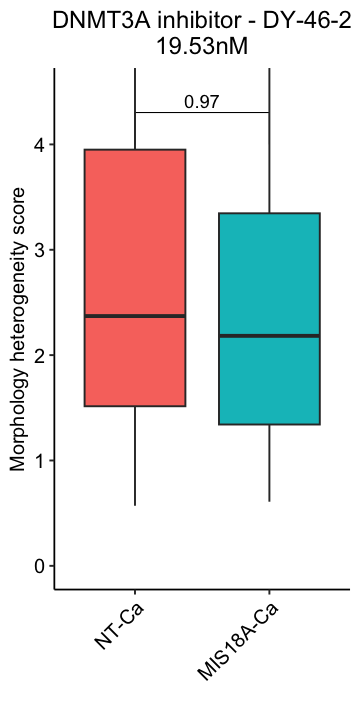

In [10]:
options(repr.plot.width = 3, repr.plot.height = 6)
plt_dnmt3ai